## 0.1 Access the Datasets

In [14]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

#url = 'https://raw.githubusercontent.com/mcnakhaee/palmerpenguins/refs/heads/master/palmerpenguins/data/penguins.csv'
#url2 =  'https://raw.githubusercontent.com/mcnakhaee/palmerpenguins/refs/heads/master/palmerpenguins/data/penguins-raw.csv'

url = './data/penguins.csv'
penguins = pd.read_csv(url)

print(penguins.shape)
penguins.head()

(344, 8)


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


In [17]:
# copy both penguin datasets to local
url = 'https://raw.githubusercontent.com/mcnakhaee/palmerpenguins/refs/heads/master/palmerpenguins/data/penguins.csv'
url2 =  'https://raw.githubusercontent.com/mcnakhaee/palmerpenguins/refs/heads/master/palmerpenguins/data/penguins-raw.csv'
pd.read_csv(url).to_csv('./data/penguins.csv', index=False)
pd.read_csv(url2).to_csv('./data/penguins_raw.csv', index=False)

## 1.2 Correlation vs. Causation

In [18]:
corr = penguins.corr(numeric_only=True)
corr

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year
bill_length_mm,1.000000,-0.235053,0.656181,0.595110,0.054545
bill_depth_mm,-0.235053,1.000000,-0.583851,-0.471916,-0.060354
flipper_length_mm,0.656181,-0.583851,1.000000,0.871202,0.169675
body_mass_g,0.595110,-0.471916,0.871202,1.000000,0.042209
year,0.054545,-0.060354,0.169675,0.042209,1.000000


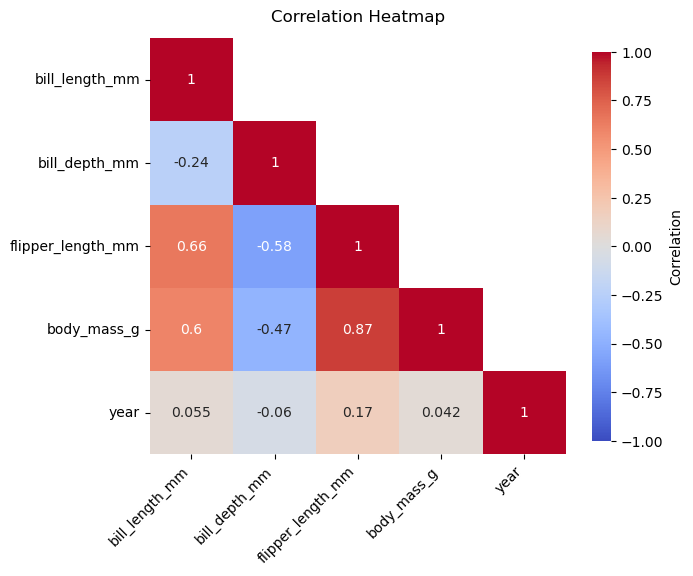

In [35]:
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)  # mask upper triangle

# create the heatmap you see below - use seaborn sns.heatmap


plt.figure(figsize=(7,6))
ax = sns.heatmap(
    corr,
    mask=mask,
    annot=True,          # show numbers
    #fmt=".2f",           # two decimals
    cmap="coolwarm",       
    vmin=-1, vmax=1,     # fix range for correlation
    center=0,
    square=True,         # square cells
    #linewidths=.75,      # grid lines
    cbar_kws={"shrink": .85, "label": "Correlation"}
)

plt.title("Correlation Heatmap", pad=12)

# Rotate tick labels for readability (like your example)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()


In [26]:
mask

array([[False,  True,  True,  True,  True],
       [False, False,  True,  True,  True],
       [False, False, False,  True,  True],
       [False, False, False, False,  True],
       [False, False, False, False, False]])

## 1.4 Choosing the Right Test

| Question Type | Variable Type | Test |
|---|---|---|
| Compare 2 means | Numeric + 2 groups | t-test |
| Compare 3+ means | Numeric + 3+ groups | ANOVA |
| Compare proportions | Categorical | Chi-square |
| Numeric relationship | Numeric | Correlation/Regression |

-----
### independent t-test (two sample independent t-test)
----
There is no official "scale" to evaluate the t-score as it depends heavily on sample size / degrees of freedom. That said, these can be used for intuition:  

In large samples:  
|t| ≈ 2 → borderline significance  
|t| ≈ 3–4 → strong evidence  
|t| ≥ 10 → extremely strong evidence  


In [41]:
# equal_var=False ensure Welch's t-test (does not assume equal variances)
# equal_var=True ensure Student's t-test (pooled variance)
from scipy.stats import ttest_ind

male = penguins[penguins['sex']=='male']['body_mass_g'].dropna()
female = penguins[penguins['sex']=='female']['body_mass_g'].dropna()

# use ttest_ind to determine your t-statistic, p-score, and df

ttest_ind(a=male, b=female, equal_var=False)

TtestResult(statistic=np.float64(8.554537231165762), pvalue=np.float64(4.793891255051492e-16), df=np.float64(323.89588102864843))

In [42]:
male.shape, female.shape

((168,), (165,))

-----
### test for variances
----
* p > 0.05 → Fail to reject null → Variances are equal (Student’s t-test OK)  
* p ≤ 0.05 → Reject null → Variances are different (Use Welch’s t-test)  


In [40]:
from scipy.stats import levene

stat, p = levene(male, female)
print(stat, p)

6.058617438712248 0.014348206700435228


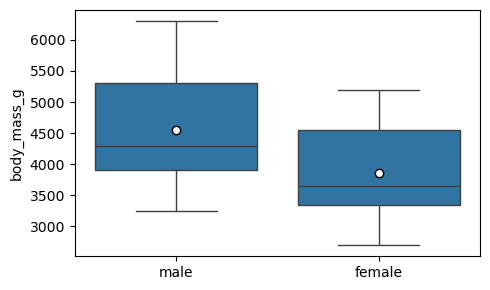

In [38]:
plt.figure(figsize=(5, 3))
df_sex = penguins[['sex','body_mass_g']].dropna()
sns.boxplot(data = df_sex, x='sex', y='body_mass_g', showmeans=True,
            meanprops={'marker':'o','markerfacecolor':'white','markeredgecolor':'black'})
plt.xlabel('')
plt.tight_layout()
plt.show()


------
### Confidence Intervals
-----

In [43]:
from scipy.stats import t

def welch_ci(x, y, alpha=0.05):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    x = x[np.isfinite(x)]
    y = y[np.isfinite(y)]

    n1, n2 = len(x), len(y)
    m1, m2 = np.mean(x), np.mean(y)
    s1, s2 = np.var(x, ddof=1), np.var(y, ddof=1)

    # Standard error for Welch
    se = np.sqrt(s1/n1 + s2/n2)

    # Welch–Satterthwaite degrees of freedom
    df = (s1/n1 + s2/n2)**2 / ((s1/n1)**2/(n1-1) + (s2/n2)**2/(n2-1))

    # Critical t
    tcrit = t.ppf(1 - alpha/2, df)

    diff = m1 - m2
    ci_low = diff - tcrit * se
    ci_high = diff + tcrit * se

    return diff, (ci_low, ci_high), df


##################################################

def student_ci(x, y, alpha=0.05):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    x = x[np.isfinite(x)]
    y = y[np.isfinite(y)]

    n1, n2 = len(x), len(y)
    m1, m2 = np.mean(x), np.mean(y)
    s1, s2 = np.var(x, ddof=1), np.var(y, ddof=1)

    # Pooled variance
    sp2 = ((n1-1)*s1 + (n2-1)*s2) / (n1 + n2 - 2)
    se = np.sqrt(sp2 * (1/n1 + 1/n2))

    df = n1 + n2 - 2
    tcrit = t.ppf(1 - alpha/2, df)

    diff = m1 - m2
    ci_low = diff - tcrit * se
    ci_high = diff + tcrit * se

    return diff, (ci_low, ci_high), df


In [50]:
# Use the functions above to return the proper CIs, as well as the difference and dof
#welch_ci(male, female)
diff, ci, df = welch_ci(male, female, alpha=0.05)


print("Mean difference:", diff)
print("95% CI:", ci)
print("df (???):", df)


Mean difference: 683.4117965367964
95% CI: (np.float64(526.245331570964), np.float64(840.5782615026287))
df (???): 323.89588102864855


* On average, male penguins are 683 grams heavier than female penguins. Because the number is positive this means male - female > 0.  
* We are 95% confident that male penguins are between 526 g and 841 g heavier than female penguins in the population.  
* Degrees of freedom is non-integer as the variances were unequal. 


-----
## One-Way ANOVA
----
* We have 1 categorical independent variable (the "factor")  
* 3 or more groups / levels  
* Comparing the mean differences in a numeric dependent variable

In [54]:
from scipy.stats import f_oneway

adelie = penguins[penguins['species']=='Adelie']['body_mass_g'].dropna()
chinstrap = penguins[penguins['species']=='Chinstrap']['body_mass_g'].dropna()
gentoo = penguins[penguins['species']=='Gentoo']['body_mass_g'].dropna()

f_oneway(adelie, chinstrap, gentoo, equal_var=True)

F_onewayResult(statistic=np.float64(343.62627520548085), pvalue=np.float64(2.892368133377531e-82))

The F-statistic tells us how much bigger the variation between group means is relative to the variation within each group.  
  
F ≈ 1 → group means are similar  
F > 3 → meaningful difference  
F > 10 → very strong evidence  
Huge F → groups differ dramatically  

In [55]:
# which group differs? ANOVA doesn't explain which differs.
import statsmodels.api as sm
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey = pairwise_tukeyhsd(
        endog=penguins['body_mass_g'].dropna(),
        groups=penguins['species'][penguins['body_mass_g'].notna()],
        alpha=0.05
        )
print(tukey)

     Multiple Comparison of Means - Tukey HSD, FWER=0.05      
  group1    group2  meandiff p-adj    lower     upper   reject
--------------------------------------------------------------
   Adelie Chinstrap   32.426 0.8807 -126.5002  191.3522  False
   Adelie    Gentoo 1375.354    0.0 1243.1786 1507.5294   True
Chinstrap    Gentoo 1342.928    0.0  1178.481  1507.375   True
--------------------------------------------------------------


------
### Chi-square test of independence
-----
* Question: Are species and island independent in the penguins dataset?  
* H₀ (null): Species and island are independent (no association)   
* H₁ (alt): Species and island are associated (not independent)   

In [56]:
ct = pd.crosstab(penguins['species'], penguins['island'])
print("Contingency table:\n", ct, "\n")


Contingency table:
 island     Biscoe  Dream  Torgersen
species                            
Adelie         44     56         52
Chinstrap       0     68          0
Gentoo        124      0          0 



In [59]:
from scipy.stats import chi2_contingency
chi2, p, dof, expected = chi2_contingency(ct)

print(f"Chi-square statistic: {chi2:.3f}")
print(f"Degrees of freedom: {dof}")
print(f"p-value: {p:.6f}\n")

Chi-square statistic: 299.550
Degrees of freedom: 4
p-value: 0.000000



In [ ]:
expected_df = pd.DataFrame(expected, index=ct.index, columns=ct.columns)
print("Expected counts (if independent):\n", expected_df.round(2))

* ***Note*** You have a dof of 4 -->   3 islands / 3 species -->  (3-1)*(3-1) = 4

* p > 0.05 → Fail to reject the null hypothesis  
(“There is no evidence of association. Variables may be independent.”)  
  
  
* p < 0.05 → Reject the null hypothesis  
(“There is evidence of association. Variables are not independent.”)  

------
### Correlation / Regression
-----

In [58]:
clean = penguins[['body_mass_g','flipper_length_mm', 'bill_depth_mm']].dropna()
X = sm.add_constant(clean[['flipper_length_mm']])
y = clean['body_mass_g']
model = sm.OLS(y, X).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            body_mass_g   R-squared:                       0.759
Model:                            OLS   Adj. R-squared:                  0.758
Method:                 Least Squares   F-statistic:                     1071.
Date:                Wed, 04 Mar 2026   Prob (F-statistic):          4.37e-107
Time:                        11:20:15   Log-Likelihood:                -2528.4
No. Observations:                 342   AIC:                             5061.
Df Residuals:                     340   BIC:                             5069.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
=====================================================================================
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const             -5780.8314    305.815    -18.903      0.000   -6382.358   -5179.305
flipper_length_mm    49.6856      1.518     32.722      0.000      46.699      52.672
==============================================================================
Omnibus:                        5.634   Durbin-Watson:                   2.190
Prob(Omnibus):                  0.060   Jarque-Bera (JB):                5.585
Skew:                           0.313   Prob(JB):                       0.0613
Kurtosis:                       3.019   Cond. No.                     2.89e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.89e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""